# Oxygen Evals: Bottom Timeseries in Saanich Inlet, Satrait of Georgia Center and East

In [1]:
import xarray as xr
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from salishsea_tools import visualisations as vis
import cmocean.cm as cm

import cmocean.cm as cm
import datetime as dt
import gsw
from tqdm import tqdm
import pickle

In [2]:
mesh = nc.Dataset('/ocean/atall/MOAD/grid/mesh_mask202108.nc')
bathy = nc.Dataset('/ocean/atall/MOAD/grid/bathymetry_202108.nc')

meshb = nc.Dataset('/ocean/atall/MOAD/grid/mesh_mask_202310b.nc')
bathyb = nc.Dataset('/ocean/atall/MOAD/grid/bathymetry_202310b.nc')
grid = xr.open_dataset('/ocean/atall/MOAD/grid/bathymetry_202310b.nc', mask_and_scale=False)

depthb = meshb.variables['gdept_0'][:]


In [3]:
# ONC observation
# Obs cordonates (Saanich Inlet) : 48.651366°N, -123.486358°W, 93m
# Obs cordonates: SoG Center: 49.039467°N, -123.425033°W, 305m ; SoG Est: 49.042586°N,  -123.316579°W, 166m
df_ctd = pd.read_csv('/ocean/atall/MOAD/Obs/ONC/Saanich_Inlet/Patricia_Bay/SI_Venus_Inst_Platform/Temperature_SA_Sigmat_CTDA_20180101_20191231_clean_avg1day_edit.csv')
df_rko = pd.read_csv('/ocean/atall/MOAD/Obs/ONC/Saanich_Inlet/Patricia_Bay/SI_Venus_Inst_Platform/Temperature_Oxygen_RinkoSensor_20180101_20191231_clean_avg1day_edit.csv')
df_sogC = pd.read_csv('/ocean/atall/MOAD/Obs/ONC/SoG/SoG_Venus_Inst_Plattform/Oxygen_20180101_20191231_clean_avg1day_SoGCenter_edit.csv')
df_sogE = pd.read_csv('/ocean/atall/MOAD/Obs/ONC/SoG/SoG_Venus_Inst_Plattform/Oxygen_20180101_20191231_clean_avg1day_SoGEst_edit.csv')
df_ctd.head()

,Time UTC (yyyy-mm-ddThh:mm:ss.fffZ),Temperature (C),Practical Salinity (psu),Sigma-t (kg/m3)
0,2018-01-01T12:00:00.000Z,9.585932539,30.963502805,23.86826656
1,2018-01-02T12:00:00.000Z,9.577705381,30.934944818,23.847273839
2,2018-01-03T12:00:00.000Z,9.581542369,30.946245712,23.855487199
3,2018-01-04T12:00:00.000Z,9.578901597,30.931631389,23.844496877
4,2018-01-05T12:00:00.000Z,9.577732847,30.924635069,23.839219606


In [4]:
df_rko

,Time UTC (yyyy-mm-ddThh:mm:ss.fffZ),Temperature (C),Oxygen Concentration Corrected (ml/l)
0,2018-01-01T12:00:00.000Z,9.600959017,0.507372272
1,2018-01-02T12:00:00.000Z,9.593706987,0.634645594
2,2018-01-03T12:00:00.000Z,9.595493833,0.566978259
3,2018-01-04T12:00:00.000Z,9.594484038,0.608590795
4,2018-01-05T12:00:00.000Z,9.594025563,0.615223959
...,...,...,...
722,2019-12-26T12:00:00.000Z,9.609252352,1.215274067
723,2019-12-27T12:00:00.000Z,9.654206418,0.925476382
724,2019-12-28T12:00:00.000Z,9.624187552,1.156520922
725,2019-12-29T12:00:00.000Z,9.591318718,1.275286609


In [5]:
# Convert objet dataframe to int
df_sogC['Oxygen Concentration Corrected (ml/l)'] = pd.to_numeric(df_sogC['Oxygen Concentration Corrected (ml/l)'], errors='coerce')
df_sogE['Oxygen Concentration Corrected (ml/l)'] = pd.to_numeric(df_sogE['Oxygen Concentration Corrected (ml/l)'], errors='coerce')

df_rko['Oxygen Concentration Corrected (ml/l)'] = pd.to_numeric(df_rko['Oxygen Concentration Corrected (ml/l)'], errors='coerce')
df_rko['Temperature (C)'] = pd.to_numeric(df_rko['Temperature (C)'], errors='coerce')
df_ctd['Temperature (C)'] = pd.to_numeric(df_ctd['Temperature (C)'], errors='coerce')
df_ctd['Practical Salinity (psu)'] = pd.to_numeric(df_ctd['Practical Salinity (psu)'], errors='coerce')
df_ctd['Sigma-t (kg/m3)'] = pd.to_numeric(df_ctd['Sigma-t (kg/m3)'], errors='coerce')
time = np.arange(dt.datetime(2018,1,1), dt.datetime(2019,12,31), dt.timedelta(days=1)).astype(dt.datetime)

In [6]:
# Obs variables
oxy_sogC = df_sogC['Oxygen Concentration Corrected (ml/l)']
oxy_sogE = df_sogE['Oxygen Concentration Corrected (ml/l)']
oxy_obs = df_rko['Oxygen Concentration Corrected (ml/l)']
sal_obs = gsw.SR_from_SP(df_ctd['Practical Salinity (psu)']) # from practical to ref salinity (g/kg)
tem_obs = df_ctd['Temperature (C)']
tem_obs2 = df_rko['Temperature (C)']
sig_obs = df_ctd['Sigma-t (kg/m3)']

In [36]:
# Z2eff = 0.6, no WWTP, baseline, v202410b
df_chemTd0 = xr.open_mfdataset('/ocean/atall/MOAD/Model/202410b/oxygen/*jan18/SalishSea_1d_*_chem_T.nc')
df_biolTd0 = xr.open_mfdataset('/ocean/atall/MOAD/Model/202410b/oxygen/*jan18/SalishSea_1d_*_biol_T.nc')
df_diagTd0 = xr.open_mfdataset('/ocean/atall/MOAD/Model/202410b/oxygen/*jan18/SalishSea_1d_*_diag_T.nc')
# Z2eff = 0.6, WWTP, with Nutrients, and freshwater
df_chemTd1 = xr.open_mfdataset('/ocean/atall/MOAD/Model/202410b/wastewatero2/*jan18/SalishSea_1d_*_chem_T.nc')
df_biolTd1 = xr.open_mfdataset('/ocean/atall/MOAD/Model/202410b/wastewatero2/*jan18/SalishSea_1d_*_biol_T.nc')
df_diagTd1 = xr.open_mfdataset('/ocean/atall/MOAD/Model/202410b/wastewatero2/*jan18/SalishSea_1d_*_diag_T.nc')
# Z2eff = 0.6, WWTP, no Nutrients,only freshwater
df_chemTd2 = xr.open_mfdataset('/ocean/atall/MOAD/Model/202410b/wastewatero2_zeroNut/*jan18/SalishSea_1d_*_chem_T.nc')
df_biolTd2 = xr.open_mfdataset('/ocean/atall/MOAD/Model/202410b/wastewatero2_zeroNut/*jan18/SalishSea_1d_*_biol_T.nc')
df_diagTd2 = xr.open_mfdataset('/ocean/atall/MOAD/Model/202410b/wastewatero2_zeroNut/*jan18/SalishSea_1d_*_diag_T.nc')


In [12]:
grid_dir = Path("/ocean/atall/MOAD/grid/")
grid_map = Path("grid_from_lat_lon_mask999.nc")
grid_lons_lats = xr.open_dataset(grid_dir / grid_map)
meshmask = xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask_202310b.nc')
tmask = meshmask.tmask
#tmask = tmask.rename({'z' : 'depth', 'y': 'gridY', 'x': 'gridX'})
mbathy = meshmask.mbathy
#grid_lons_lats

In [13]:
j_SI = grid_lons_lats.jj.sel(lats=48.651366, lons=-123.486358, method='nearest') # 93 m (Obs)
i_SI = grid_lons_lats.ii.sel(lats=48.651366, lons=-123.486358, method='nearest')
j_SoG = grid_lons_lats.jj.sel(lats=49.039467, lons=-123.425033, method='nearest') # 305 m (Obs)
i_SoG = grid_lons_lats.ii.sel(lats=49.039467, lons=-123.425033, method='nearest')
j_SoGE = grid_lons_lats.jj.sel(lats=49.042586, lons=-123.316579, method='nearest') # 305 m (Obs)
i_SoGE = grid_lons_lats.ii.sel(lats=49.042586, lons=-123.316579, method='nearest')
print((j_SI.item(),i_SI.item()), (j_SoG.item(),i_SoG.item()), (j_SoGE.item(),i_SoGE.item()))

(353, 209) (423, 266) (416, 283)


In [14]:
print(bathyb.variables['Bathymetry'][j_SI, i_SI], bathyb.variables['Bathymetry'][j_SoG, i_SoG], bathyb.variables['Bathymetry'][j_SoGE, i_SoGE])

103.875 305.8125 163.4375


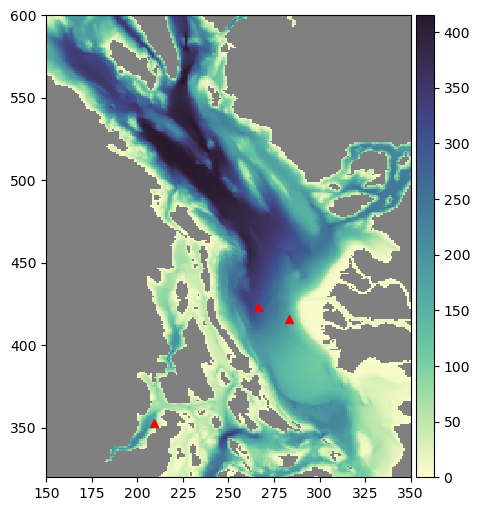

In [11]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


fig, ax = plt.subplots(1, 1, figsize=(5, 6))
mycmap = cm.deep
mycmap.set_bad('grey')
im = ax.pcolormesh(bathy.variables['Bathymetry'][:], cmap=mycmap, vmin=0, vmax=415)
ax.plot(i_SI,j_SI,'r^')
ax.plot(i_SoG,j_SoG,'r^')
ax.plot(i_SoGE,j_SoGE,'r^')
ax.set_xlim([150, 350])
ax.set_ylim([320, 600])
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical')


# 

Text(0.5, 1.0, '')

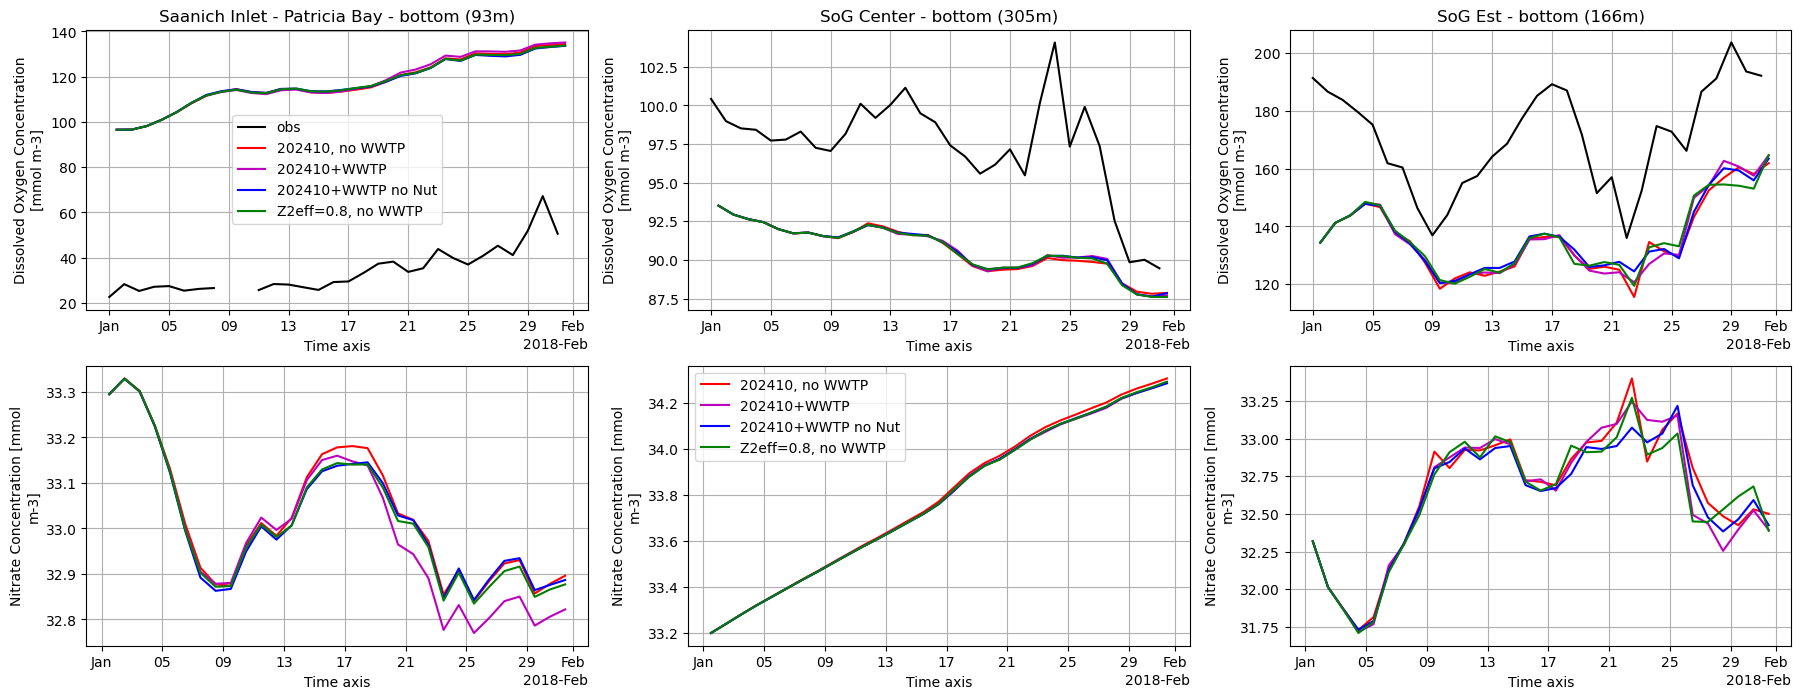

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(22, 8))
ax[0,0].plot(time[:31],oxy_obs[:31] * 44.661, 'k',label='obs')
df_chemTd0['dissolved_oxygen'][:, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI].where(tmask[0, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI] == 1).plot(ax=ax[0,0], x="time_counter", color='r',label='202410, no WWTP')
df_chemTd1['dissolved_oxygen'][:, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI].where(tmask[0, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI] == 1).plot(ax=ax[0,0], x="time_counter", color='m',label='202410+WWTP')
df_chemTd2['dissolved_oxygen'][:, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI].where(tmask[0, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI] == 1).plot(ax=ax[0,0], x="time_counter", color='b',label='202410+WWTP no Nut')
#df_chemTd3['dissolved_oxygen'][:, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI].where(tmask[0, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI] == 1).plot(ax=ax[0,0], x="time_counter", color='g',label='Z2eff=0.8, no WWTP')
ax[0,1].plot(time[:31],oxy_sogC[:31] * 44.661, 'k', label='obs')
ax[0,2].plot(time[:31],oxy_sogE[:31] * 44.661, 'k', label='obs')
df_chemTd0['dissolved_oxygen'][:, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG].where(tmask[0, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG] == 1).plot(ax=ax[0,1], x="time_counter", color='r',label='202410, no WWTP')
df_chemTd0['dissolved_oxygen'][:, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE].where(tmask[0, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE] == 1).plot(ax=ax[0,2], x="time_counter", color='r',label='202410, no WWTP')
df_chemTd1['dissolved_oxygen'][:, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG].where(tmask[0, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG] == 1).plot(ax=ax[0,1], x="time_counter", color='m',label='202410+WWTP')
df_chemTd1['dissolved_oxygen'][:, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE].where(tmask[0, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE] == 1).plot(ax=ax[0,2], x="time_counter", color='m',label='202410+WWTP')
df_chemTd2['dissolved_oxygen'][:, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG].where(tmask[0, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG] == 1).plot(ax=ax[0,1], x="time_counter", color='b',label='202410+WWTP no Nut')
df_chemTd2['dissolved_oxygen'][:, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE].where(tmask[0, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE] == 1).plot(ax=ax[0,2], x="time_counter", color='b',label='202410+WWTP no Nut')
#df_chemTd3['dissolved_oxygen'][:, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG].where(tmask[0, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG] == 1).plot(ax=ax[0,1], x="time_counter", color='g',label='Z2eff=0.8, no WWTP')
#df_chemTd3['dissolved_oxygen'][:, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE].where(tmask[0, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE] == 1).plot(ax=ax[0,2], x="time_counter", color='g',label='Z2eff=0.8, no WWTP')

df_biolTd0['nitrate'][:, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI].where(tmask[0, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI] == 1).plot(ax=ax[1,0], x="time_counter", color='r',label='202410, no WWTP')
df_biolTd1['nitrate'][:, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI].where(tmask[0, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI] == 1).plot(ax=ax[1,0], x="time_counter", color='m',label='202410+WWTP')
df_biolTd2['nitrate'][:, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI].where(tmask[0, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI] == 1).plot(ax=ax[1,0], x="time_counter", color='b',label='202410+WWTP no Nut')
#df_biolTd3['nitrate'][:, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI].where(tmask[0, mbathy[0, j_SI, i_SI]-1, j_SI, i_SI] == 1).plot(ax=ax[1,0], x="time_counter", color='g',label='Z2eff=0.8, no WWTP')
df_biolTd0['nitrate'][:, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG].where(tmask[0, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG] == 1).plot(ax=ax[1,1], x="time_counter", color='r',label='202410, no WWTP')
df_biolTd0['nitrate'][:, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE].where(tmask[0, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE] == 1).plot(ax=ax[1,2], x="time_counter", color='r',label='202410, no WWTP')
df_biolTd1['nitrate'][:, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG].where(tmask[0, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG] == 1).plot(ax=ax[1,1], x="time_counter", color='m',label='202410+WWTP')
df_biolTd1['nitrate'][:, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE].where(tmask[0, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE] == 1).plot(ax=ax[1,2], x="time_counter", color='m',label='202410+WWTP')
df_biolTd2['nitrate'][:, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG].where(tmask[0, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG] == 1).plot(ax=ax[1,1], x="time_counter", color='b',label='202410+WWTP no Nut')
df_biolTd2['nitrate'][:, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE].where(tmask[0, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE] == 1).plot(ax=ax[1,2], x="time_counter", color='b',label='202410+WWTP no Nut')
#df_biolTd3['nitrate'][:, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG].where(tmask[0, mbathy[0, j_SoG, i_SoG]-1, j_SoG, i_SoG] == 1).plot(ax=ax[1,1], x="time_counter", color='g',label='Z2eff=0.8, no WWTP')
#df_biolTd3['nitrate'][:, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE].where(tmask[0, mbathy[0, j_SoGE, i_SoGE]-1, j_SoGE, i_SoGE] == 1).plot(ax=ax[1,2], x="time_counter", color='g',label='Z2eff=0.8, no WWTP')


ax[0,0].grid()
ax[1,0].grid()
ax[0,1].grid()
ax[1,1].grid()
ax[0,0].legend()
ax[1,1].legend()
ax[0,2].grid()
ax[1,2].grid()
#ax[2].legend()
ax[0,0].set_title('Saanich Inlet - Patricia Bay - bottom (93m)')
ax[0,1].set_title('SoG Center - bottom (305m)')
ax[0,2].set_title('SoG Est - bottom (166m)')
ax[1,0].set_title('')
ax[1,1].set_title('')
ax[1,2].set_title('')
#fig.savefig('../figures_WQM-KC/DO_Obs-202111-2024XX-2024XXc-2024XXb-2024XXd_PatriciaBay.png',dpi = 300)

In [11]:
ds_sources = xr.open_dataset("/ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon_xygrid_clim.nc")
flux_nonzero = ds_sources["flux"].max(dim="time_counter") > 0
source_indices = np.argwhere(flux_nonzero.values)
lon = ds_sources["nav_lon"].values
lat = ds_sources["nav_lat"].values

print(f"Found {len(source_indices)} sources")

Found 94 sources


In [12]:
dx = 2   # grid size for local mean extraction
labels = ["Baseline", "WWTP-noNut", "WWTP-withNut"]

variables = {
    "O2": ("dissolved_oxygen", [df_chemTd0, df_chemTd2, df_chemTd1]),
    "NO3": ("nitrate", [df_biolTd0, df_biolTd2, df_biolTd1]),
    "NH3": ("ammonium", [df_biolTd0, df_biolTd2, df_biolTd1]),
    "Z2": ("mesozooplankton", [df_biolTd0, df_biolTd2, df_biolTd1]),
}

diag_terms = {
    "PRD_O2": "PRD_O2",
    "REM_O2": "REM_O2",
    "PHS_O2": "PHS_O2",
    "BIO_O2": "BIO_O2",
    "dDO_dt": "RATE_O2",
}


In [13]:
def extract_local_mean(df, var_name, y, x, dx=2):
    """Local mean around point (y,x), over time"""
    sub = np.array(df[var_name][:, :, y-dx:y+dx+1, x-dx:x+dx+1])
    return np.nanmean(sub, axis=(2, 3))

def extract_diag(df, terms, y, x, dx=2):
    """Extract diagnostic terms local mean around point (y,x), over time"""
    diag = {}
    for name, var in terms.items():
        diag[name] = extract_local_mean(df, var, y, x, dx)
    return diag

In [21]:
results = {}

for idx, (y, x) in tqdm(enumerate(source_indices), total=len(source_indices)):
    res_source = {}
    
    # Variable timeseries 
    for var_name, (var_key, dfs) in variables.items():
        series = []
        for df in dfs:
            ts = extract_local_mean(df, var_key, y, x, dx)
            series.append(ts)
        res_source[var_name] = series  # [Baseline, noNut, withNut]

    # Diagnostic terms
    diag_series = []
    for df in [df_diagTd0, df_diagTd2, df_diagTd1]:
        diag = extract_diag(df, diag_terms, y, x, dx)
        diag_series.append(diag)
    res_source["Diag"] = diag_series

    results[idx] = res_source

  0%|          | 0/94 [00:00<?, ?it/s]/tmp/ipykernel_242912/1126769930.py:4: RuntimeWarning: Mean of empty slice
  return np.nanmean(sub, axis=(2, 3))


100%|██████████| 94/94 [4:44:19<00:00, 181.48s/it]  


In [22]:
# Save results to a pickle file
with open("WWTP_results.pkl", "wb") as f:
    pickle.dump(results, f)

In [28]:
# Dataframe construction
records_main = []
records_diag = []

yy, xx = zip(*source_indices)
lon_sources = lon[0, yy, xx]
lat_sources = lat[0, yy, xx]

for idx, res in results.items():
    lon_i = lon_sources[idx]
    lat_i = lat_sources[idx]
    ntime = len(res["O2"][0])

    # DO and NO3 series
    for var_name in ["O2", "NO3", "NH3", "Z2"]:
        for sim_name, sim_label in zip(res[var_name], ["Baseline", "WWTP_noNut", "WWTP_withNut"]):
            for t, val in enumerate(sim_name):
                records_main.append({
                    "source_id": idx,
                    "lon": lon_i,
                    "lat": lat_i,
                    "time_index": t,
                    "variable": var_name,
                    "simulation": sim_label,
                    "value": val
                })
    
    # Diagnostics series
    for sim_diag, sim_label in zip(res["Diag"], ["Baseline", "WWTP_noNut", "WWTP_withNut"]):
        for diag_name, diag_series in sim_diag.items():
            for t, val in enumerate(diag_series):
                records_diag.append({
                    "source_id": idx,
                    "lon": lon_i,
                    "lat": lat_i,
                    "time_index": t,
                    "diag_term": diag_name,
                    "simulation": sim_label,
                    "value": val
                })

# DataFrames creation
df_main = pd.DataFrame.from_records(records_main)
df_diag = pd.DataFrame.from_records(records_diag)

print(f"Local timeseries : {df_main.shape}")
print(f"DO Diagnostics : {df_diag.shape}")

# Save to CSV
df_main.to_csv("WWTP_local_series.csv", index=False)
df_diag.to_csv("WWTP_diagnostics.csv", index=False)

print("Saved files : WWTP_local_series.csv and WWTP_DOdiagnostics.csv")


Local timeseries : (32148, 7)
DO Diagnostics : (43710, 7)
Saved files : WWTP_local_series.csv and WWTP_DOdiagnostics.csv


In [29]:
df_main[df_main["variable"] == "O2"].head()


,source_id,lon,lat,time_index,variable,simulation,value
0,0,-122.640366,47.143044,0,O2,Baseline,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
1,0,-122.640366,47.143044,1,O2,Baseline,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
2,0,-122.640366,47.143044,2,O2,Baseline,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
3,0,-122.640366,47.143044,3,O2,Baseline,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
4,0,-122.640366,47.143044,4,O2,Baseline,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."


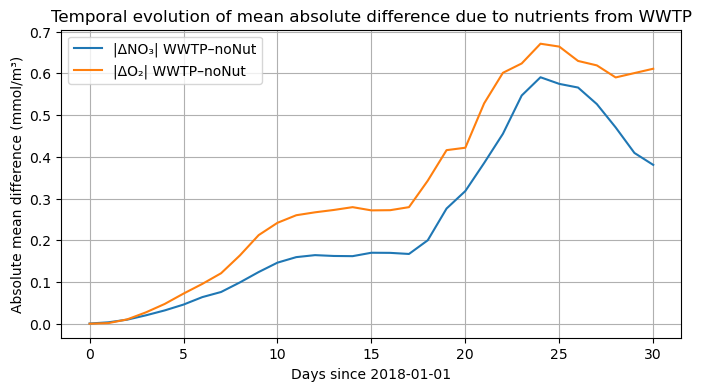

In [11]:
diff_series_NO3 = np.mean(np.abs(df_biolTd1['nitrate'] - df_biolTd2['nitrate']), axis=(1,2,3))
diff_series_DO  = np.mean(np.abs(df_chemTd1['dissolved_oxygen'] - df_chemTd2['dissolved_oxygen']), axis=(1,2,3))

plt.figure(figsize=(8,4))
plt.plot(diff_series_NO3*8, label="|ΔNO₃| WWTP–noNut")
plt.plot(diff_series_DO, label="|ΔO₂| WWTP–noNut")
plt.xlabel('Days since 2018-01-01');
plt.ylabel('Absolute mean difference (mmol/m³)')
plt.legend(); plt.title('Temporal evolution of mean absolute difference due to nutrients from WWTP')
plt.grid()
plt.show()

/home/atall/miniforge3/envs/analysis-abdoul/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/atall/miniforge3/envs/analysis-abdoul/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_2423646/2872429384.py:15: RuntimeWarning: Mean of empty slice
  corr_WC = np.nanmean(corr_map, axis=0)


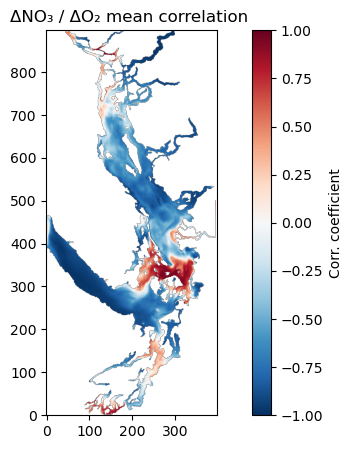

In [12]:
dNO3 = np.array(df_biolTd1['nitrate'][1:,:,:,:] - df_biolTd1['nitrate'][0,:,:,:])
dDO  = np.array(df_chemTd1['dissolved_oxygen'][1:,:,:,:] - df_chemTd1['dissolved_oxygen'][0,:,:,:])

T, Z, Y, X = dNO3.shape
corr_map = np.zeros((Z, Y, X))

for z in range(Z):
    for y in range(Y):
        for x in range(X):
            corr = np.corrcoef(dNO3[:,z,y,x], dDO[:,z,y,x])[0,1]
            corr_map[z,y,x] = corr


# Mean correlation over the water column
corr_WC = np.nanmean(corr_map, axis=0)

plt.figure(figsize=(9,5))
plt.imshow(corr_WC, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('ΔNO₃ / ΔO₂ mean correlation ')
plt.colorbar(label='Corr. coefficient')
plt.show()

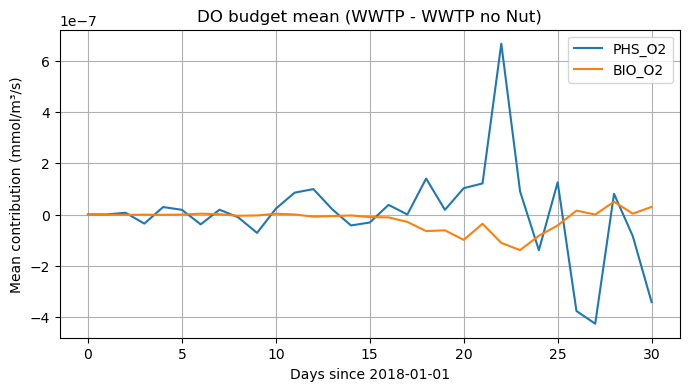

In [11]:
terms = ['PHS_O2', 'BIO_O2']
colors = ['#1f77b4','#ff7f0e']

fig, ax = plt.subplots(figsize=(8,4))
for term, col in zip(terms, colors):
    mean_term = np.nanmean(df_diagTd1[term]-df_diagTd2[term], axis=(1,2,3))
    #mean_term2 = np.nanmean(df_diagTd2[term], axis=(1,2,3))
    ax.plot(mean_term, label=term, color=col)
    #ax.plot(mean_term2, label=term, linestyle='dashed', color=col)

ax.legend()
ax.set_title('DO budget mean (WWTP - WWTP no Nut)')
ax.set_xlabel('Days since 2018-01-01')
ax.set_ylabel('Mean contribution (mmol/m³/s)')
ax.grid()
plt.show()

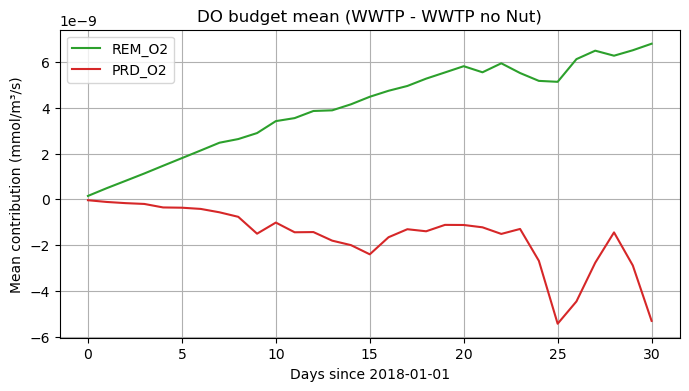

In [12]:
terms = ['REM_O2', 'PRD_O2']
colors = ['#2ca02c','#d62728']

fig, ax = plt.subplots(figsize=(8,4))
for term, col in zip(terms, colors):
    mean_term = np.nanmean(np.abs(df_diagTd1[term])-np.abs(df_diagTd2[term]), axis=(1,2,3))
    #mean_term2 = np.nanmean(df_diagTd2[term], axis=(1,2,3))
    ax.plot(mean_term, label=term, color=col)
    #ax.plot(mean_term2, label=term, linestyle='dashed', color=col)

ax.legend()
ax.set_title('DO budget mean (WWTP - WWTP no Nut)')
ax.set_xlabel('Days since 2018-01-01')
ax.set_ylabel('Mean contribution (mmol/m³/s)')
ax.grid()
plt.show()

In [15]:
clevels = np.linspace(0, 317, 40)
#clevels = [0,65,100,120,200,250,300]
thalweg_file = '/ocean/atall//MOAD/analysis-abdoul/notebooks/thalweg_work/thalweg_files/thalweg_working.txt'
thalweg_file2 = '/ocean/atall/MOAD/analysis-abdoul/notebooks/thalweg_work/thalweg_files/Saanich_thalweg.txt'
thalweg_file3 = '/ocean/atall/MOAD/analysis-abdoul/notebooks/thalweg_work/thalweg_files/JoseTallthalwegPS.txt'
thalweg_file4 = '/ocean/atall/MOAD/analysis-abdoul/notebooks/thalweg_work/thalweg_files/JosethalwegPS.txt'
thalweg_pts = np.loadtxt(thalweg_file, delimiter=' ', dtype=int)
thalweg_pts2 = np.loadtxt(thalweg_file2, delimiter=' ', dtype=int)
thalweg_pts3 = np.loadtxt(thalweg_file3, delimiter=' ', dtype=int)
thalweg_pts4 = np.loadtxt(thalweg_file4, delimiter=' ', dtype=int)

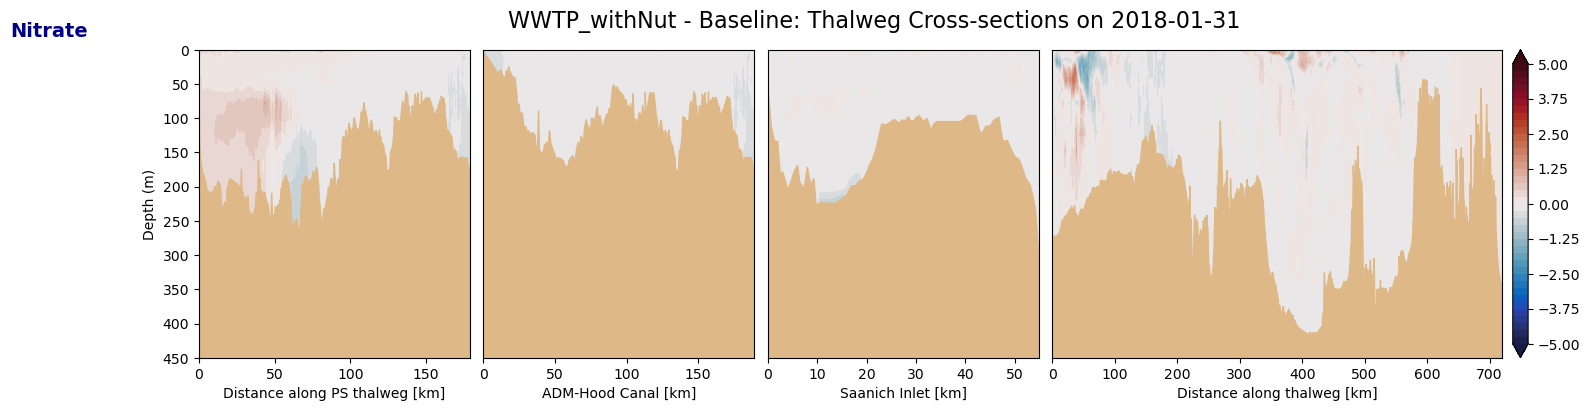

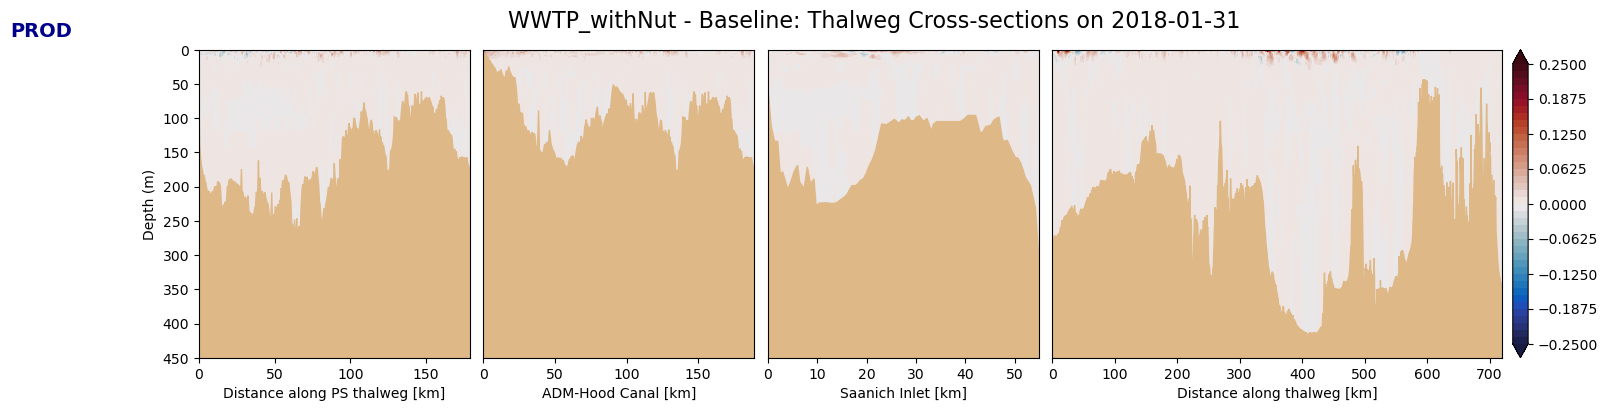

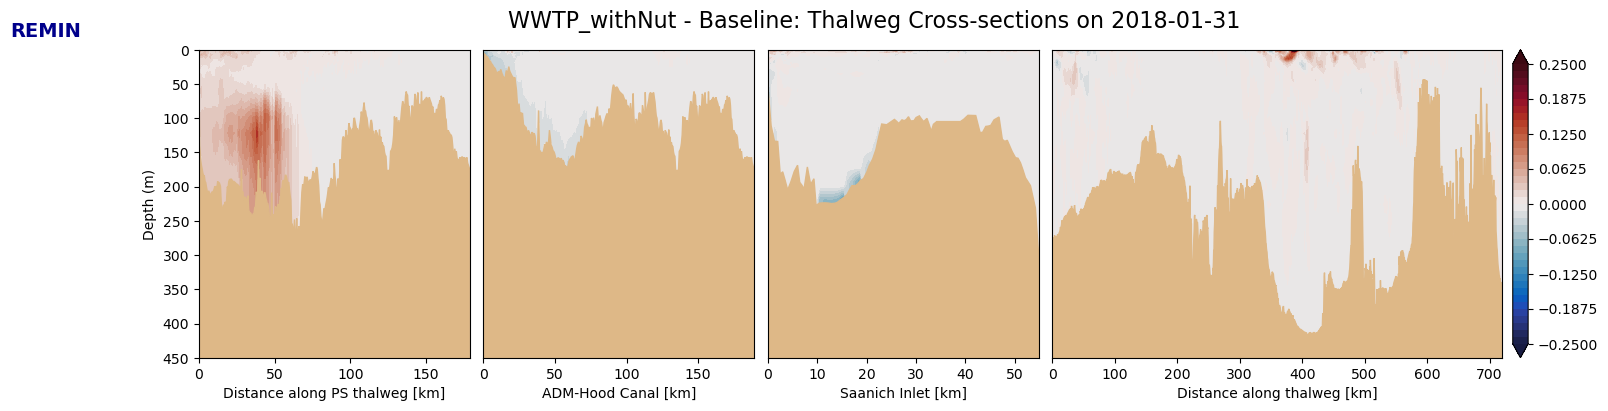

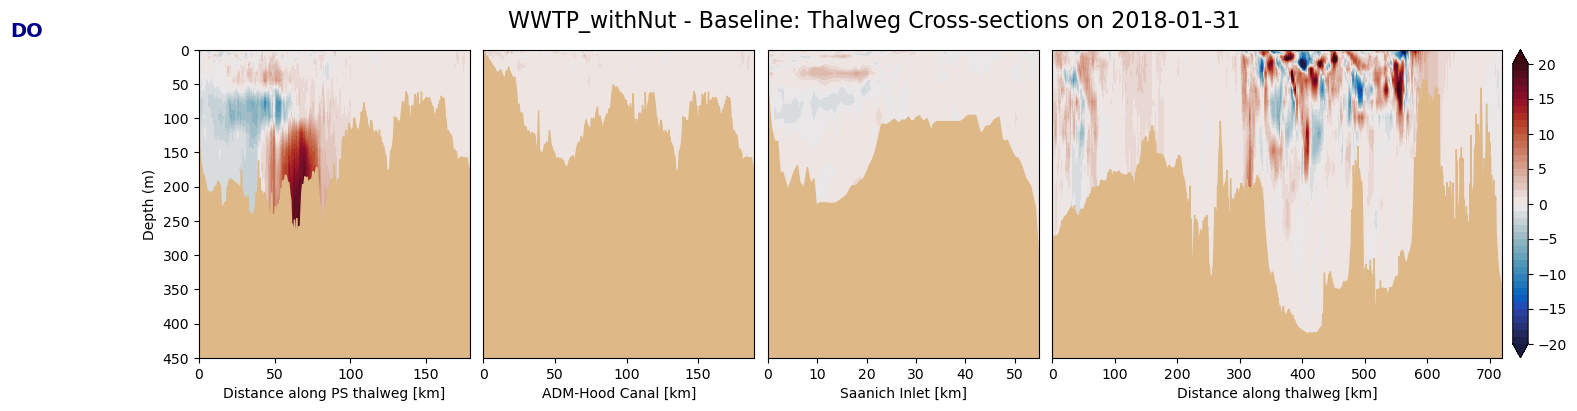

In [39]:
cmap = cm.balance

# Define thalwegs and labels
thalwegs = [thalweg_pts4, thalweg_pts3, thalweg_pts2[::-1], thalweg_pts]
labels = ['Distance along PS thalweg [km]',
          'ADM-Hood Canal [km]',
          'Saanich Inlet [km]',
          'Distance along thalweg [km]']
width_ratios = [0.5, 0.5, 0.5, 1]

clevels_dict = {
    'DO': np.linspace(-20, 20, 41),  
    'Nitrate': np.linspace(-5, 5, 41),
    'PROD': np.linspace(-0.25, 0.25, 41),
    'REMIN': np.linspace(-0.25, 0.25, 41),
}

di = 30
ndays = 1
for i in range(ndays):
    var1 = np.array(df_biolTd1['nitrate'][i+di, :, :, :]) - np.array(df_biolTd0['nitrate'][i+di, :, :, :])
    var2 = (np.array(df_diagTd1['PRD_O2'][i+di, :, :, :]) - np.array(df_diagTd0['PRD_O2'][i+di, :, :, :])) * 86400
    var3 = (np.array(df_diagTd1['REM_O2'][i+di, :, :, :]) - np.array(df_diagTd0['REM_O2'][i+di, :, :, :])) * 86400
    var4 = np.array(df_chemTd1['dissolved_oxygen'][i+di, :, :, :]) - np.array(df_chemTd0['dissolved_oxygen'][i+di, :, :, :])

    for j, (var, var_name) in enumerate(zip([var1, var2, -var3, var4], ['Nitrate', 'PROD', 'REMIN','DO'])):
        fig, ax = plt.subplots(1, 4, figsize=(18, 4), gridspec_kw={'width_ratios': [0.5, 0.5, 0.5, 1]})

        date_str = str(df_chemTd1['time_counter'][i+di].values)[:10]

        fig.suptitle(f"WWTP_withNut - Baseline: Thalweg Cross-sections on {date_str}", fontsize=16)
        fig.text(0.02, 0.95, var_name, fontsize=14, fontweight='bold', color='darkblue', va='top')

        clevels = clevels_dict[var_name]

        for k, (thal, label) in enumerate(zip(thalwegs, labels)):
            dep_thal, distance, var_thal = vis.load_thalweg(depthb[0, ...], var, bathyb['nav_lon'][:], bathyb['nav_lat'][:], thal)
            xx_thal = distance
            var_plot = vis._fill_in_bathy(var_thal, mesh, thal)
            im = ax[k].contourf(xx_thal, dep_thal, var_plot, clevels, cmap=cmap, extend='both')
            vis._add_bathy_patch(xx_thal, bathyb['Bathymetry'][:], thal, ax[k], color='burlywood')
            ax[k].set_xlabel(label)
            ax[k].set_ylim([450, 0])
            if k == 0:
                ax[k].set_ylabel('Depth (m)')
                ax[k].tick_params(left=True, right=False, labelleft=True)
            else:
                ax[k].tick_params(left=False, right=False, labelleft=False)

        cbar = plt.colorbar(im, ax=ax[3], pad=0.02)
        fig.subplots_adjust(wspace=0.04, hspace=0.1)
        # Optional: save figure
        fig.savefig(f'thalweg_WWTP_withNutminusBaseline_{i+di+1}Jan_{var_name}.png')
